# PBMC 3k — exploratory scRNA-seq analysis

## 0. Setup 

In [1]:
import sys
import scanpy as sc
import os
import numpy as np 
from scipy.stats import median_abs_deviation
import pandas as pd   

In [2]:
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

In [3]:
os.getcwd()

'/Volumes/T7 Shield/Project_CV/scrnaseq-pipeline'

## 1. Load and explore the data

### 1.1 Dataset 
 Peripheral blood mononuclear cells (PBMCs) from a healthy donor (same donor as pbmc6k) sequenced with 10x Genomics Chromium. \
 PBMCs are primary cells with relatively small amounts of RNA (~1pg RNA/cell).

In [4]:
adata = sc.datasets.pbmc3k()
adata

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'
    layers: None (.X)

### 1.2 Anndata structure
obs = cells (barcodes), var = genes, X = UMI counts

In [5]:
adata.obs # cells barcode 

""
index
AAACATACAACCAC-1
AAACATTGAGCTAC-1
AAACATTGATCAGC-1
AAACCGTGCTTCCG-1
AAACCGTGTATGCG-1
...
TTTCGAACTCTCAT-1
TTTCTACTGAGGCA-1
TTTCTACTTCCTCG-1


In [6]:
adata.var

,gene_ids
index,
MIR1302-10,ENSG00000243485
FAM138A,ENSG00000237613
OR4F5,ENSG00000186092
RP11-34P13.7,ENSG00000238009
RP11-34P13.8,ENSG00000239945
...,...
AC145205.1,ENSG00000215635
BAGE5,ENSG00000268590
CU459201.1,ENSG00000251180


In [7]:
type(adata.X) # sparse matrix do not store zero value -> save memory 


scipy.sparse._csr.csr_matrix

In [8]:
adata.X.toarray() # 0 can be a dropout an mRNA not detected 
                  # rows = cells    col = genes 

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(2700, 32738), dtype=float32)

In [9]:
adata.shape

(2700, 32738)

In [10]:
adata.X.nnz # number of non 0 value 

2286884

In [11]:
value = 1 - adata.X.nnz/(2700 * 32738)
f"{value:.1%}" # fraction of zero value 

'97.4%'

## 2. Quality Control 

### 2.1 mitochondrial genes 
In human start with "MT-". Human mitochondrial genomes has 37 genes : 13 protein-coding,  22 tRNAs and 2 rRNAs.


In [12]:
adata.var_names

Index(['MIR1302-10', 'FAM138A', 'OR4F5', 'RP11-34P13.7', 'RP11-34P13.8',
       'AL627309.1', 'RP11-34P13.14', 'RP11-34P13.9', 'AP006222.2',
       'RP4-669L17.10',
       ...
       'KIR3DL2-1', 'AL590523.1', 'CT476828.1', 'PNRC2-1', 'SRSF10-1',
       'AC145205.1', 'BAGE5', 'CU459201.1', 'AC002321.2', 'AC002321.1'],
      dtype='str', name='index', length=32738)

In [13]:
adata.var['MT-'] = adata.var_names.str.startswith('MT-') 
print("number of mitochondrial genes: " ,sum(adata.var['MT-']))

number of mitochondrial genes:  13


In [14]:
print("mitochondrial genes:" , adata.var_names[adata.var['MT-']])

mitochondrial genes: Index(['MT-ND1', 'MT-ND2', 'MT-CO1', 'MT-CO2', 'MT-ATP8', 'MT-ATP6', 'MT-CO3',
       'MT-ND3', 'MT-ND4L', 'MT-ND4', 'MT-ND5', 'MT-ND6', 'MT-CYB'],
      dtype='str', name='index')


### 2.2 QC metrics 
Mitochondrial percentage (pct_counts_MT-): \
Is calculated because damaged, dying, or stressed cells often have unusually high mitochondrial RNA fractions.\
\
Library size (total_counts): \
cells with small library sizes are of low quality as the RNA has been lost at some point during library preparation, either due to cell lysis or inefficient cDNA capture and amplification.\
\
number of expressed features in each cell (n_genes_by_counts): \
Any cell with very few expressed genes is likely to be of poor quality as the diverse transcript population has not been successfully captured and loot of expressed genes is possibly a doublet .

In [15]:
sc.pp.calculate_qc_metrics(adata, qc_vars=["MT-"], inplace= True )

In [16]:
adata.obs

,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_MT-,log1p_total_counts_MT-,pct_counts_MT-
index,,,,,,,,,,,
AAACATACAACCAC-1,781,6.661855,2421.0,7.792349,47.748864,63.279637,74.969021,88.393226,73.0,4.304065,3.015283
AAACATTGAGCTAC-1,1352,7.210080,4903.0,8.497807,45.502753,61.023863,71.813176,82.622884,186.0,5.231109,3.793596
AAACATTGATCAGC-1,1131,7.031741,3149.0,8.055158,41.314703,53.794856,65.449349,79.961893,28.0,3.367296,0.889171
AAACCGTGCTTCCG-1,960,6.867974,2639.0,7.878534,39.029936,52.898825,66.691929,82.569155,46.0,3.850147,1.743085
AAACCGTGTATGCG-1,522,6.259581,981.0,6.889591,44.852192,55.657492,67.176351,97.757390,12.0,2.564949,1.223242
...,...,...,...,...,...,...,...,...,...,...,...
TTTCGAACTCTCAT-1,1155,7.052721,3461.0,8.149602,39.237215,52.528171,65.761341,81.074834,73.0,4.304065,2.109217
TTTCTACTGAGGCA-1,1227,7.113142,3447.0,8.145550,37.278793,51.900203,63.881636,78.909196,32.0,3.496508,0.928343
TTTCTACTTCCTCG-1,622,6.434547,1684.0,7.429521,45.783848,61.638955,74.940618,92.755344,37.0,3.637586,2.197150


In [17]:
adata.obs.describe()[["n_genes_by_counts", "total_counts","pct_counts_MT-"]]

,n_genes_by_counts,total_counts,pct_counts_MT-
count,2700.000000,2700.000000,2700.000000
mean,846.994074,2366.900391,2.215132
std,282.104964,1094.262085,1.165438
min,212.000000,548.000000,0.000000
25%,690.000000,1757.750000,1.536238
50%,817.000000,2197.000000,2.029639
75%,953.250000,2763.000000,2.640218
max,3422.000000,15844.000000,22.569027


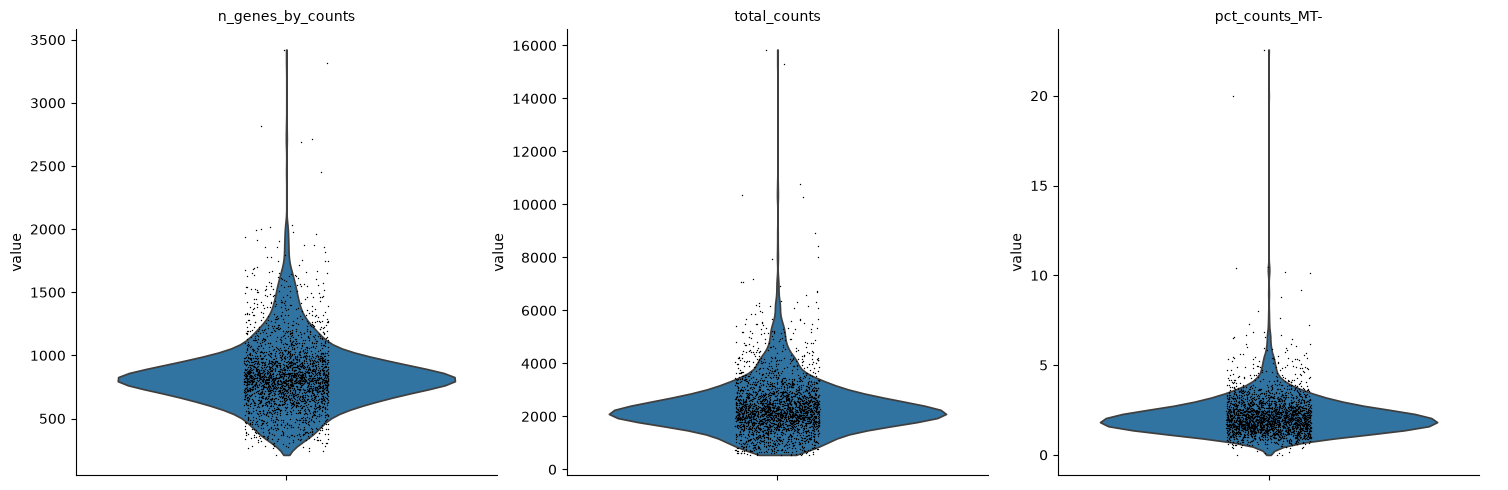

In [18]:
sc.pl.violin(adata, keys = ["n_genes_by_counts", "total_counts","pct_counts_MT-"], multi_panel=True )

### 2.3 MAD-based outlier detection
identify cells that are outliers for the different QC metrics 

In [19]:
def is_outlier(adata,col_name , nMAD,upper_only=False):
    MAD = median_abs_deviation(adata.obs[col_name])
    median = np.median(adata.obs[col_name])
    thresh_pos   = median + nMAD * MAD
    
    if upper_only == True:
        mask = adata.obs[col_name] > thresh_pos
        print("nb of oulier",col_name,"above:", sum(adata.obs[col_name] > thresh_pos))
        print("thresh used:" , "above", thresh_pos)
        
    else:
        thresh_under = median - nMAD * MAD
        mask = (adata.obs[col_name] > thresh_pos) | (adata.obs[col_name] < thresh_under)
        print("nb of oulier",col_name, ":", sum(mask))
        print("nb of oulier",col_name,"above:", sum(adata.obs[col_name] > thresh_pos))
        print("nb of oulier",col_name,"under:", sum(adata.obs[col_name] < thresh_under))
        print("thresh used:" , "above", thresh_pos, " and under " , thresh_under)
    return mask

adata.obs['outlier_n_genes_by_counts'] = is_outlier(adata, "log1p_n_genes_by_counts", 5)
adata.obs['outlier_total_counts'] = is_outlier(adata, "log1p_total_counts", 5)
adata.obs['outlier_pct_counts_MT-'] = is_outlier(adata, "pct_counts_MT-", 3, upper_only= True)
 

nb of oulier log1p_n_genes_by_counts : 79
nb of oulier log1p_n_genes_by_counts above: 20
nb of oulier log1p_n_genes_by_counts under: 59
thresh used: above 7.507217075898423  and under  5.90650759730707
nb of oulier log1p_total_counts : 58
nb of oulier log1p_total_counts above: 13
nb of oulier log1p_total_counts under: 45
thresh used: above 8.826466  and under  6.5641403
nb of oulier pct_counts_MT- above: 202
thresh used: above 3.6501262


In [20]:
adata.obs["qc_fail"] = (adata.obs['outlier_n_genes_by_counts'])|(adata.obs['outlier_total_counts'] )|(adata.obs['outlier_pct_counts_MT-'] )
print("outlier_n_genes_by_counts:",sum(adata.obs["outlier_n_genes_by_counts"]))
print("outlier_total_counts:",sum(adata.obs["outlier_total_counts"]))
print("outlier_pct_counts_MT-:",sum(adata.obs["outlier_pct_counts_MT-"]))
print("qc_fail:",sum(adata.obs["qc_fail"]))
print("% of outlier: ",adata.obs["qc_fail"].mean())

outlier_n_genes_by_counts: 79
outlier_total_counts: 58
outlier_pct_counts_MT-: 202
qc_fail: 266
% of outlier:  0.09851851851851852


### 2.4 Filtering cells
266 cells filtered based on MAD on the 3 metrics 

In [21]:
adata_clean = adata[~adata.obs["qc_fail"]].copy()
print("nb cells removed:",adata.n_obs - adata_clean.n_obs)

nb cells removed: 266


### 2.5 Filtering genes
19259 genes filtered

In [22]:
sc.pp.filter_genes(adata_clean,min_cells=3)
adata_clean

AnnData object with n_obs × n_vars = 2434 × 13479
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_MT-', 'log1p_total_counts_MT-', 'pct_counts_MT-', 'outlier_n_genes_by_counts', 'outlier_total_counts', 'outlier_pct_counts_MT-', 'qc_fail'
    var: 'gene_ids', 'MT-', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    layers: None (.X)

## 3. Doublet detection
Sometimes two cells end up in the same droplet and theyr RNA gets the same barcode.

### 3.1 Scrublet
Creates artificial doublets by adding together the counts of random pairs of real cells.\
Puts real and artificial cells together and finds, for each real cell, its nearest neighbors.\
A real cell surrounded by many artificial doublets gets a high doublet score

In [23]:
sc.pp.scrublet(adata_clean,random_state=0) # added doublet_score and predicted_doublet

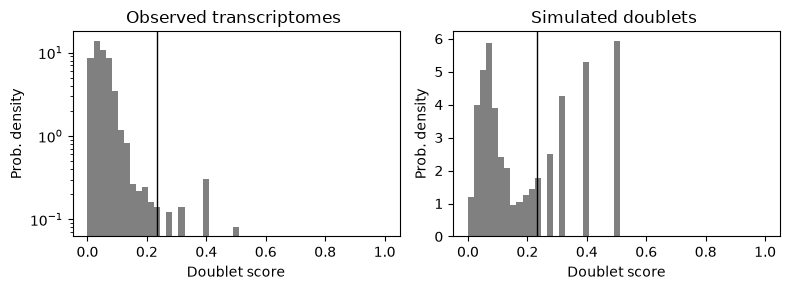

In [24]:
sc.pl.scrublet_score_distribution(adata_clean)

In [25]:
adata_clean.uns['scrublet']['threshold'] # threshold used 

np.float64(0.2329221944243316)

In [26]:
print("nb of cells predicted has doublet:",sum(adata_clean.obs.predicted_doublet))
print("% of cells predicted has doublet:",adata_clean.obs["predicted_doublet"].mean())

nb of cells predicted has doublet: 39
% of cells predicted has doublet: 0.01602300739523418


In [27]:
adata_clean = adata_clean[~adata_clean.obs["predicted_doublet"]].copy()

In [28]:
adata_clean

AnnData object with n_obs × n_vars = 2395 × 13479
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_MT-', 'log1p_total_counts_MT-', 'pct_counts_MT-', 'outlier_n_genes_by_counts', 'outlier_total_counts', 'outlier_pct_counts_MT-', 'qc_fail', 'doublet_score', 'predicted_doublet'
    var: 'gene_ids', 'MT-', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'scrublet'
    layers: None (.X)

## 4. Normalization 

### 4.1 save raw count

In [29]:
adata_clean.layers["counts"] = adata_clean.X.copy() # store the original counts matrix  
adata_clean.layers["counts"]

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 2046415 stored elements and shape (2395, 13479)>

### 4.2 Normalize 

In [30]:
sc.pp.normalize_total(adata_clean)

In [31]:
adata_clean

AnnData object with n_obs × n_vars = 2395 × 13479
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_MT-', 'log1p_total_counts_MT-', 'pct_counts_MT-', 'outlier_n_genes_by_counts', 'outlier_total_counts', 'outlier_pct_counts_MT-', 'qc_fail', 'doublet_score', 'predicted_doublet'
    var: 'gene_ids', 'MT-', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'scrublet'
    layers: None (.X), 'counts'

In [32]:
adata_clean.X.sum(axis=1)[:5] # normalized

matrix([[2239.9998],
        [2239.9998],
        [2239.9998],
        [2240.    ],
        [2240.    ]], dtype=float32)

In [33]:
adata_clean.layers["counts"].sum(axis=1)[:5] # original counts

matrix([[2419.],
        [3147.],
        [2639.],
        [ 980.],
        [2163.]], dtype=float32)

### 4.3 Log transformation 

In [34]:
sc.pp.log1p(adata_clean)

In [35]:
adata_clean.X.sum(axis=1)[:5] # normalized + log transformation 

matrix([[767.5888 ],
        [912.29736],
        [886.39264],
        [731.0765 ],
        [791.7793 ]], dtype=float32)

In [36]:
adata_clean.layers["log1p_norm"] = adata_clean.X.copy() # store log normalized counts

adata_clean.layers["log1p_norm"] contains log normalized counts \
adata_clean.layers["counts"] contains the original counts 

In [37]:
print(np.max(adata_clean.layers["log1p_norm"] ))
print(np.max(adata_clean.layers["counts"]))

5.7521214
419.0


## 5. Feature selection 

In [38]:
sc.pp.highly_variable_genes(adata_clean,
                            layer="counts",
                            flavor="seurat_v3",
                            n_top_genes= 2000)

A normalized variance for each gene is computed. First, the data are standardized (i.e., z-score normalization per feature) with a regularized standard deviation. Next, the normalized variance is computed as the variance of each gene after the transformation. Genes are ranked by the normalized variance.

In [39]:
adata_clean.var["highly_variable_rank"].sort_values()[0:15]

index
LYZ         0.0
S100A9      1.0
FTL         2.0
IGLL5       3.0
GNLY        4.0
FTH1        5.0
S100A8      6.0
FCER1A      7.0
NKG7        8.0
HLA-DRA     9.0
CST3       10.0
CCL4       11.0
GZMB       12.0
C1QA       13.0
PPBP       14.0
Name: highly_variable_rank, dtype: float32

## 6. Dimensionality reduction

### 6.1 scale 

In [40]:
sc.pp.scale(adata_clean, max_value=10) # scale to compare gene 

/opt/anaconda3/envs/scrnaseq-pipeline/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [41]:
adata_clean.X.mean(axis=0)[:5] # mean of 5 first gene expected +- 0

array([-0.02275332, -0.02246725, -0.02237632, -0.02265627, -0.01474211])

In [42]:
adata_clean.X.std(axis=0)[:5] # sd of 5 first gene 

array([0.61556381, 0.35493979, 0.35493657, 0.35494648, 0.80835673])

### 6.2 PCA

In [43]:
sc.tl.pca(adata_clean,
          n_comps=50,
         random_state=0,
         mask_var='highly_variable')

In [44]:
adata_clean

AnnData object with n_obs × n_vars = 2395 × 13479
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_MT-', 'log1p_total_counts_MT-', 'pct_counts_MT-', 'outlier_n_genes_by_counts', 'outlier_total_counts', 'outlier_pct_counts_MT-', 'qc_fail', 'doublet_score', 'predicted_doublet'
    var: 'gene_ids', 'MT-', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'scrublet', 'log1p', 'hvg', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: None (.X), 'counts', 'log1p_norm'

### 6.3 elbow plot to chose number of PC to use 

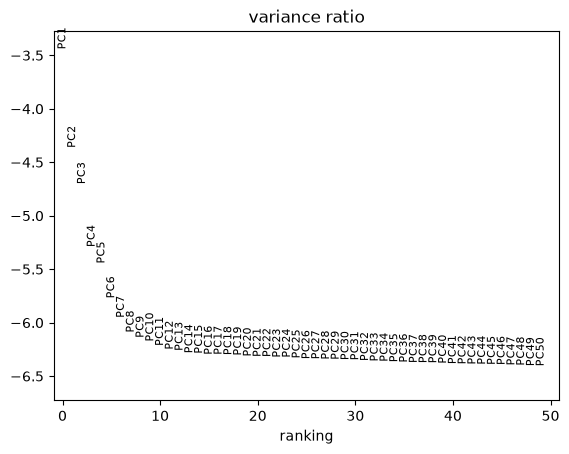

In [45]:
sc.pl.pca_variance_ratio(adata_clean,log=True,n_pcs=50)

### 6.4 PCA plot 

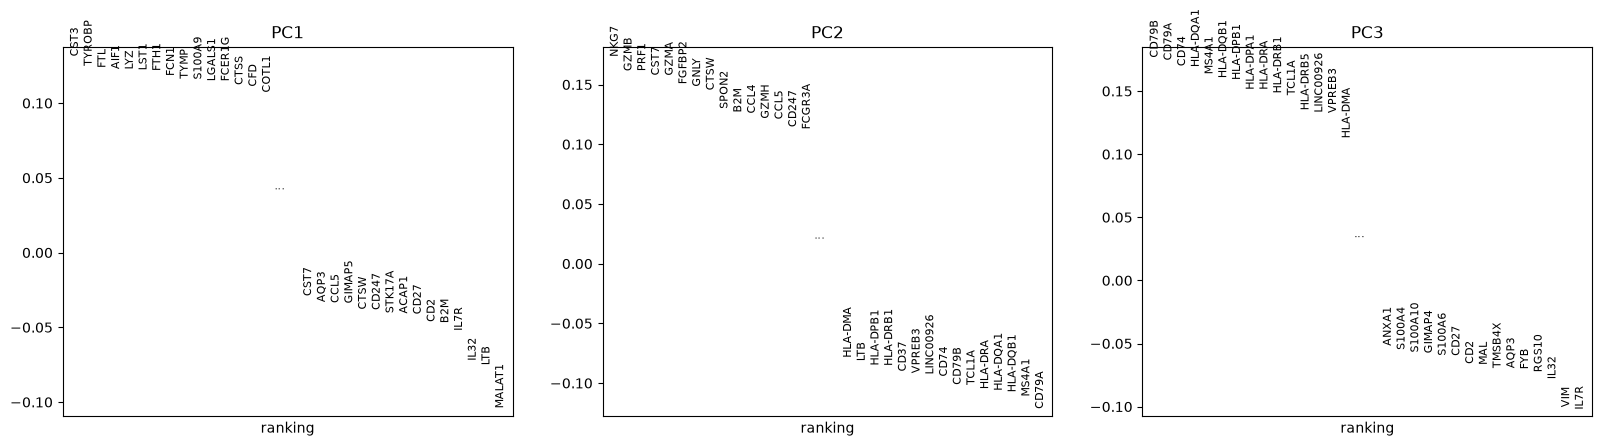

In [46]:
sc.pl.pca_loadings(adata_clean)

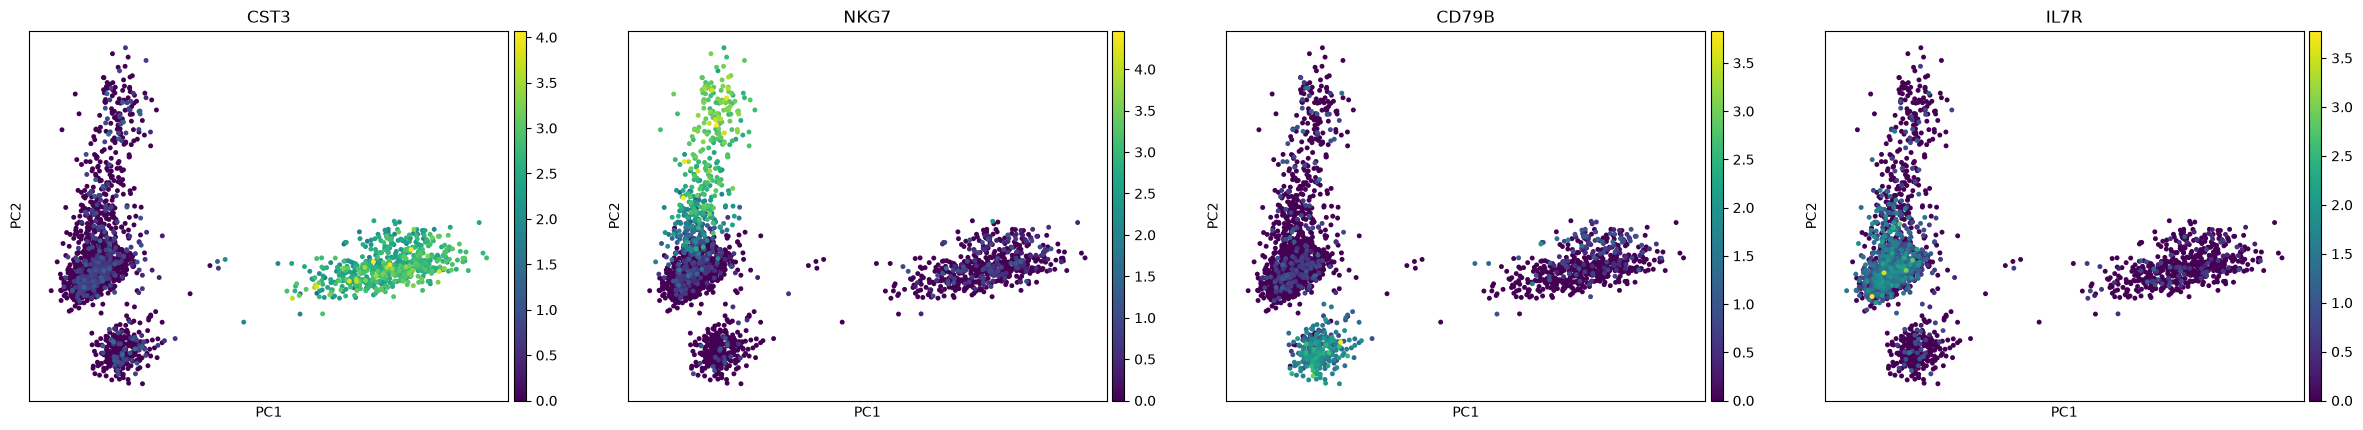

In [47]:
sc.pl.pca(adata_clean,color=["CST3", "NKG7", "CD79B",'IL7R',],layer="log1p_norm")

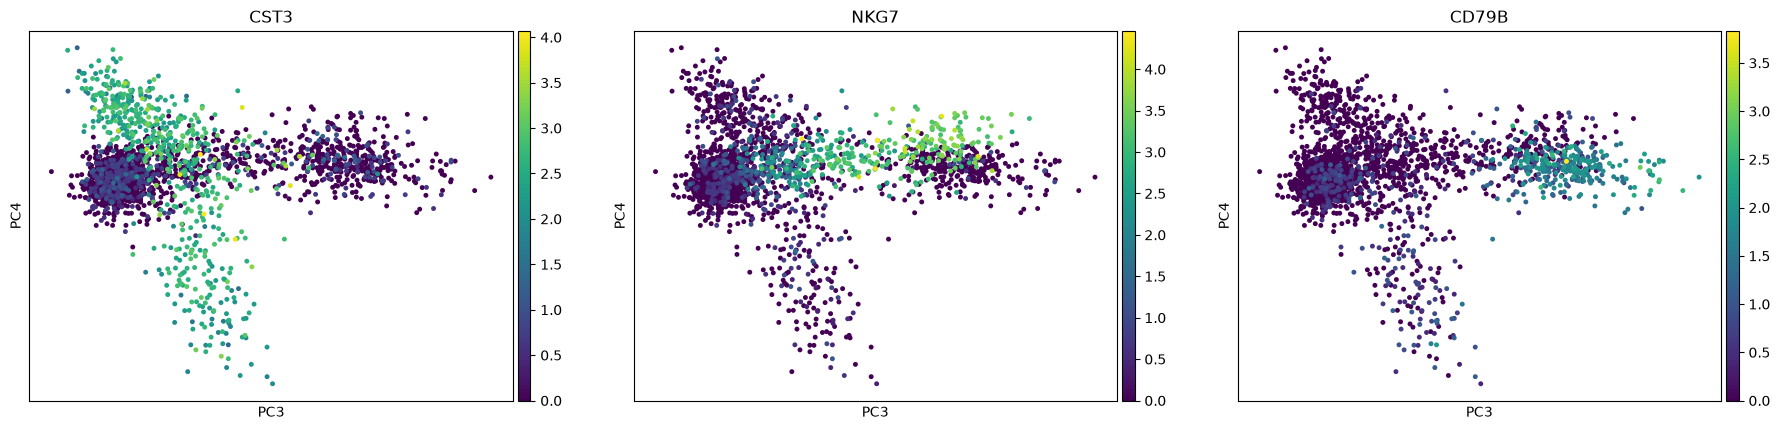

In [48]:
sc.pl.pca(adata_clean,color=["CST3", "NKG7", "CD79B"],layer="log1p_norm",
         components=["3,4"])

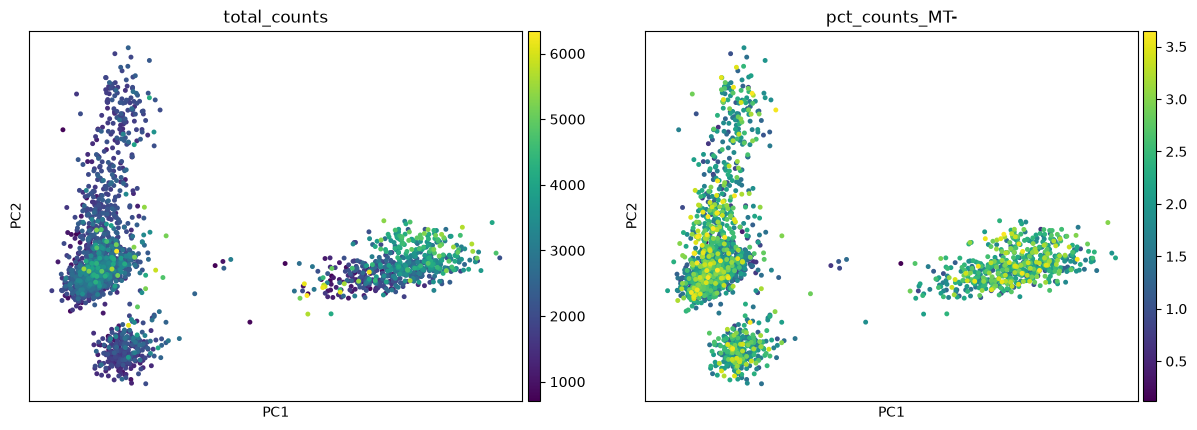

In [49]:
sc.pl.pca(adata_clean, color=["total_counts", "pct_counts_MT-"])

## 7. neighbors, UMAP and clustering.

### 7.1 neighbor graph

In [50]:
sc.pp.neighbors(adata_clean,n_pcs=15,random_state=0)

/opt/anaconda3/envs/scrnaseq-pipeline/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [51]:
adata_clean.obsp['distances']

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 33530 stored elements and shape (2395, 2395)>

### 7.2 UMAP

In [52]:
sc.tl.umap(adata_clean,random_state=0)

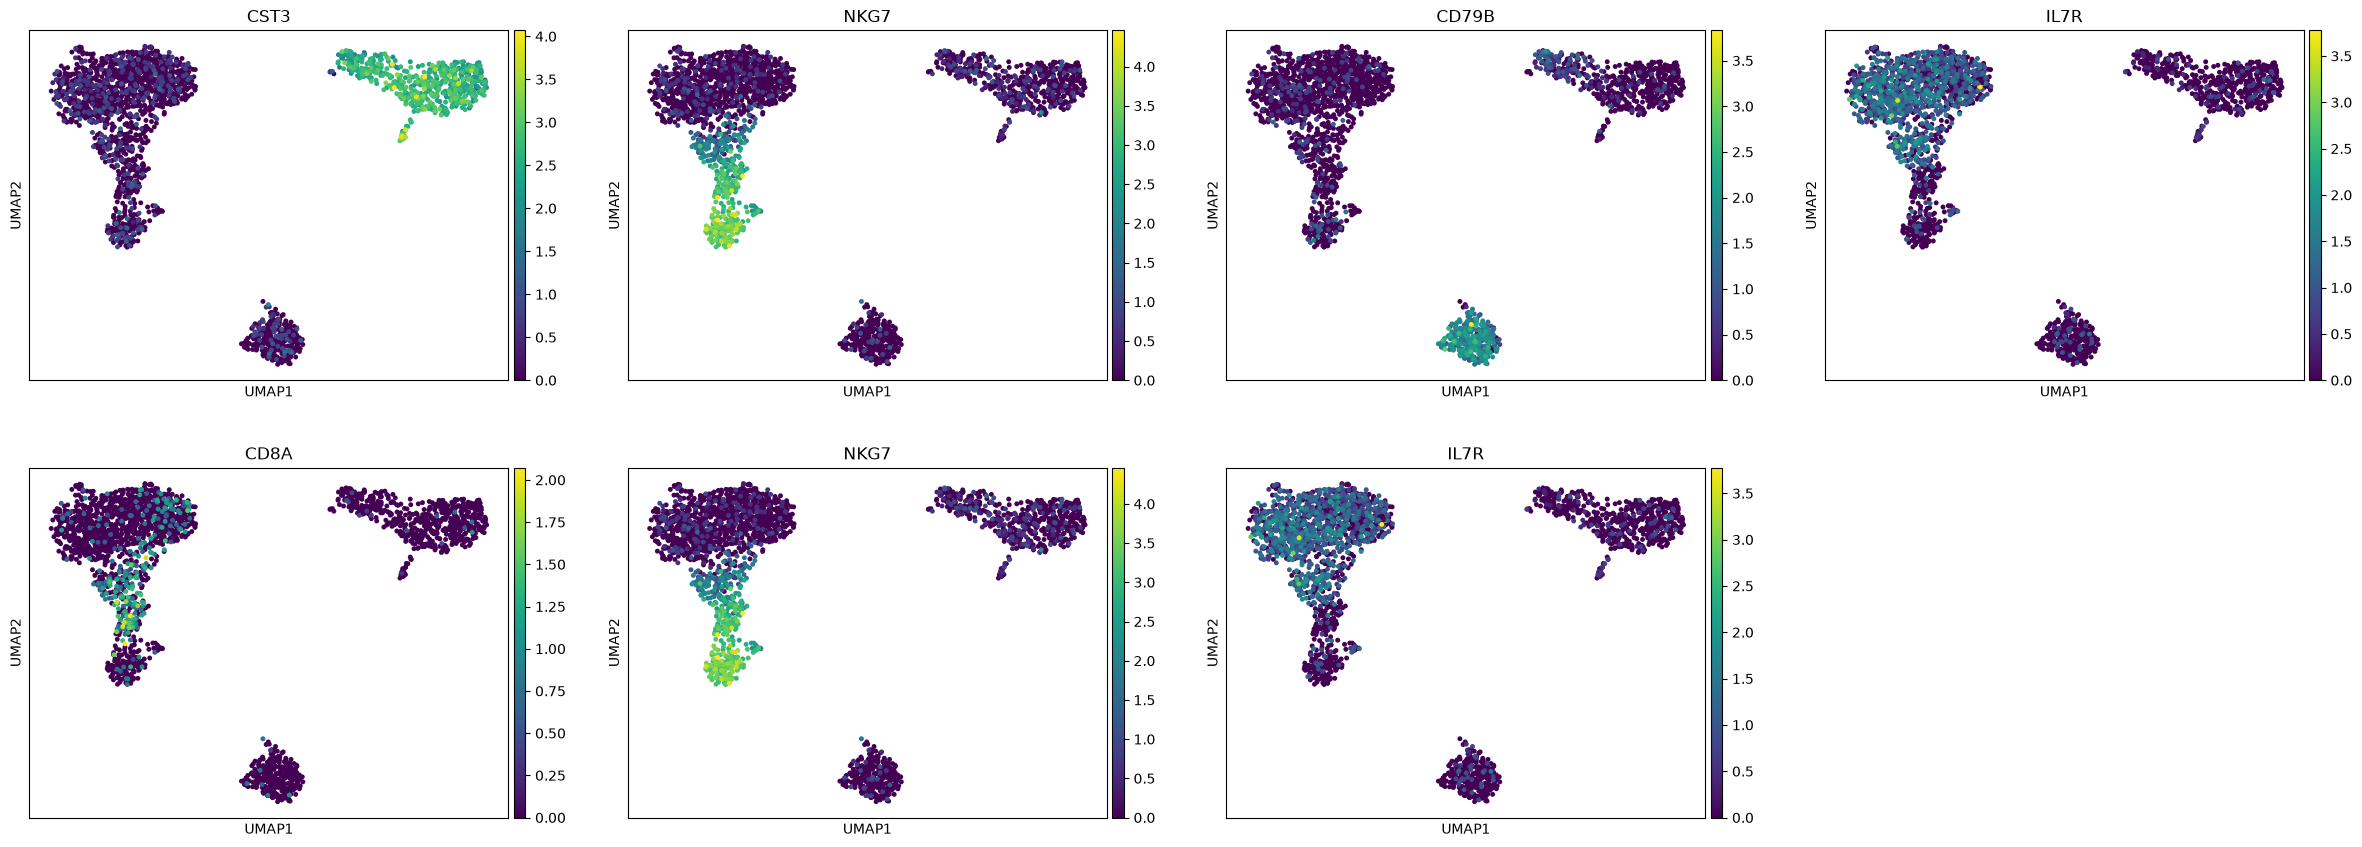

In [53]:
sc.pl.umap(adata_clean,layer="log1p_norm",color=["CST3", "NKG7", "CD79B",'IL7R',"CD8A","NKG7","IL7R"])

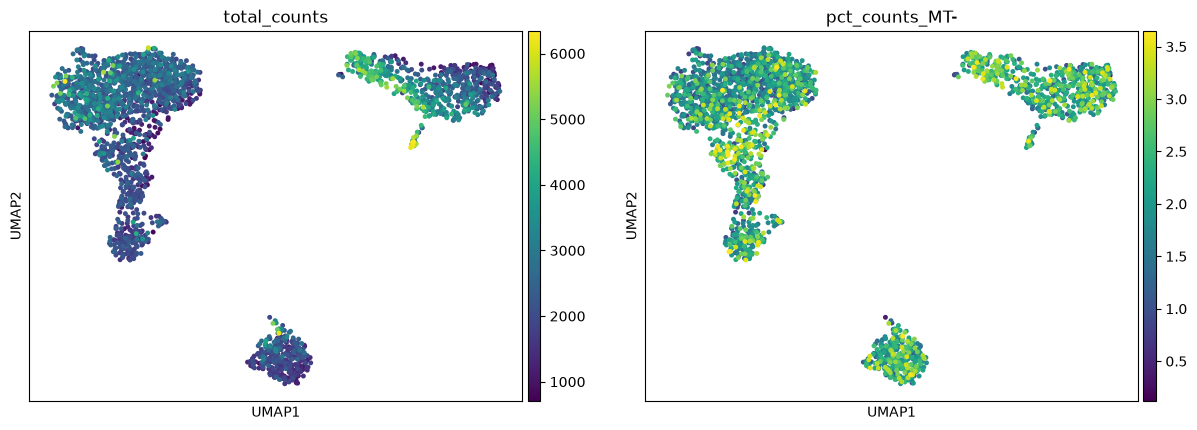

In [54]:
sc.pl.umap(adata_clean,layer="log1p_norm",color=["total_counts", "pct_counts_MT-"])

### 7.3 Leiden (0.5 and 1.0) 

leiden_0.5
0    275
1    520
2    418
3    153
4    146
5    299
6    559
7     25
Name: count, dtype: int64


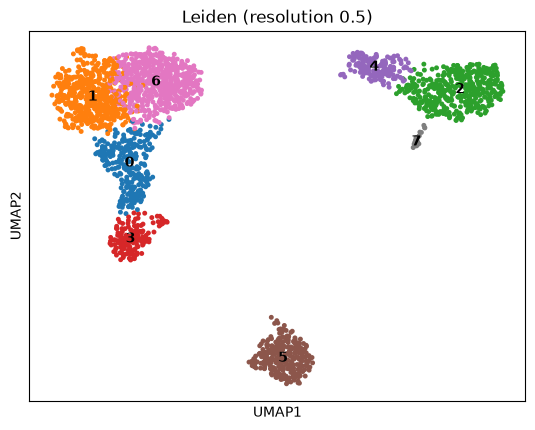

In [55]:


# --- Leiden clustering at resolution 0.5 ---
sc.tl.leiden(
    adata_clean,
    resolution=0.5,          # lower = fewer, bigger clusters; higher = more, smaller clusters
    flavor="igraph",         # faster implementation, recommended in recent Scanpy versions
    n_iterations=2,          # number of optimization passes (recommended with flavor="igraph")
    random_state=0,          # makes the result reproducible
    key_added="leiden_0.5",  # name of the new column in adata_clean.obs
)

# Number of cells per cluster
print(adata_clean.obs["leiden_0.5"].value_counts().sort_index())

# UMAP colored by cluster, with the cluster numbers written on the plot
sc.pl.umap(adata_clean, color="leiden_0.5", legend_loc="on data", title="Leiden (resolution 0.5)")

leiden_1.0
0    290
1    479
2    562
3    180
4    153
5    140
6    299
7    244
8     23
9     25
Name: count, dtype: int64


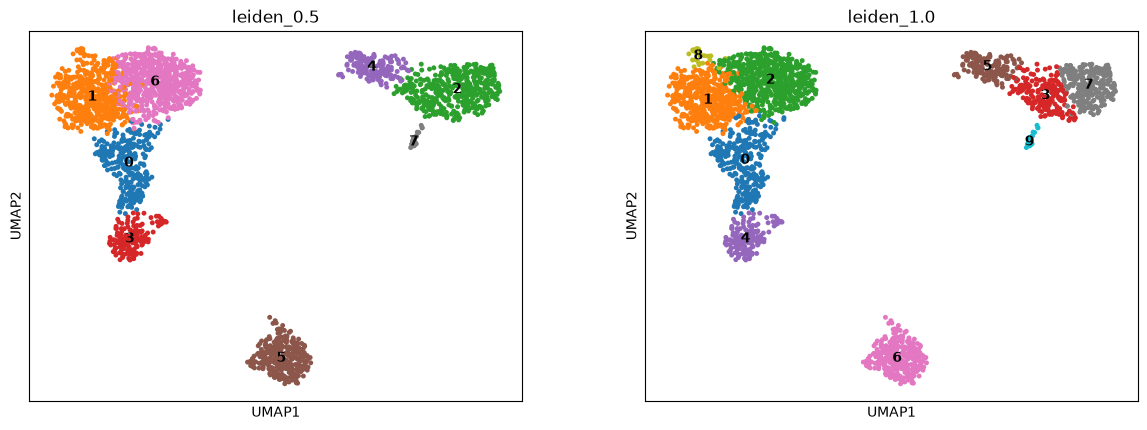

In [56]:
# --- Same clustering at a higher resolution, stored in a separate column ---
sc.tl.leiden(
    adata_clean,
    resolution=1.0,
    flavor="igraph",
    n_iterations=2,
    random_state=0,
    key_added="leiden_1.0",
)

print(adata_clean.obs["leiden_1.0"].value_counts().sort_index())

# Both resolutions side by side
sc.pl.umap(adata_clean, color=["leiden_0.5", "leiden_1.0"], legend_loc="on data")

In [57]:
pd.crosstab(adata_clean.obs["leiden_0.5"], adata_clean.obs["leiden_1.0"])

leiden_1.0,0,1,2,3,4,5,6,7,8,9
leiden_0.5,,,,,,,,,,
0,275,0,0,0,0,0,0,0,0,0
1,3,463,31,0,0,0,0,0,23,0
2,0,0,0,174,0,0,0,244,0,0
3,0,0,0,0,153,0,0,0,0,0
4,0,0,0,6,0,140,0,0,0,0
5,0,0,0,0,0,0,299,0,0,0
6,12,16,531,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,25


### 8. Marker genes for all the clusters

In [75]:
sc.tl.rank_genes_groups(
    adata_clean,
    groupby="leiden_1.0",    
    method="wilcoxon",
    layer="log1p_norm",
    pts=True,
    key_added="markers",
)

In [76]:
markers_df = sc.get.rank_genes_groups_df(adata_clean, group=None, key="markers")

# Keep strong, significant markers
markers_df = markers_df[(markers_df["pvals_adj"] < 0.05) & (markers_df["logfoldchanges"] > 1)]

# Top 10 per group
top_markers = markers_df.groupby("group", observed=True).head(10)
top_markers.to_csv("results/marker_genes.csv", index=False)


In [77]:
top_markers[top_markers['group']== "0"]

,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,0,CCL5,25.347361,5.021646,9.609326e-142,1.295241e-137,0.979310,0.216152
1,0,NKG7,20.784500,3.886343,5.978464e-96,4.029186e-92,0.900000,0.213777
3,0,CST7,17.382032,3.356345,1.128826e-67,3.803860e-64,0.737931,0.121615
5,0,GZMA,16.695858,3.208011,1.404829e-62,3.155949e-59,0.720690,0.121140
6,0,IL32,16.646313,1.953395,3.218302e-62,6.197071e-59,0.948276,0.509739
7,0,CTSW,16.322950,2.521495,6.777980e-60,1.142005e-56,0.768966,0.236580
8,0,CD3D,14.899564,1.708192,3.317391e-50,4.600625e-47,0.913793,0.480760
9,0,GZMK,14.897661,4.968095,3.413180e-50,4.600625e-47,0.568966,0.047506
11,0,LYAR,12.975327,2.887642,1.688740e-38,1.896877e-35,0.562069,0.126366
12,0,CD8A,12.837694,3.760276,1.008334e-37,9.708100e-35,0.513793,0.063183


In [78]:
top_markers

,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,0,CCL5,25.347361,5.021646,9.609326e-142,1.295241e-137,0.979310,0.216152
1,0,NKG7,20.784500,3.886343,5.978464e-96,4.029186e-92,0.900000,0.213777
3,0,CST7,17.382032,3.356345,1.128826e-67,3.803860e-64,0.737931,0.121615
5,0,GZMA,16.695858,3.208011,1.404829e-62,3.155949e-59,0.720690,0.121140
6,0,IL32,16.646313,1.953395,3.218302e-62,6.197071e-59,0.948276,0.509739
...,...,...,...,...,...,...,...,...
121316,9,CST3,7.730745,4.196456,1.069186e-14,2.401926e-11,1.000000,0.383122
121317,9,HLA-DRB1,7.632621,3.497702,2.300281e-14,4.429356e-11,1.000000,0.446835
121318,9,CLEC10A,7.498009,7.030603,6.479442e-14,1.091705e-10,0.880000,0.014768
121319,9,CD74,7.288823,3.184200,3.126757e-13,4.682840e-10,1.000000,0.846835


## 9. Cell type annotation

genes were taken from "https://azimuth.hubmapconsortium.org/references/#Human%20-%20PBMC" 

#### celltype.l1 

In [61]:
# dictionary of markers 
markers = { 
           "Monocyte"       : ["CTSS", "FCN1", "NEAT1", "LYZ", "PSAP", "S100A9", "AIF1", "MNDA", "SERPINA1", "TYROBP"],
           "CD4+ T cell"    : ["IL7R", "MAL", "LTB", "CD4", "LDHB", "TPT1", "TMSB10", "CD3D", "CD3G"],
           "CD8+ T cell"    : ["CD8B", "CD8A", "CD3D", "TMSB10", "HCST", "CD3G", "CTSW", "CD3E"],
           "natural killer cell" : ["NKG7", "KLRD1", "TYROBP", "GNLY", "FCER1G", "PRF1", "CD247", "KLRF1", "CST7", "GZMB"],
           "B cell"         : ["CD79A", "RALGPS2", "CD79B", "MEF2C"],
           "other T cell"   : ["CD3D",  "GZMK", "KLRB1", "NKG7", "CST7", "LYAR", "KLRG1", "GZMA"],
           "dendritic cell" : ["CD74", "HLA-DPA1", "HLA-DPB1", "HLA-DQA1", "CCDC88A", "HLA-DRA", "HLA-DMA", "CST3", "HLA-DQB1", "HLA-DRB1"],
           "Platelet"       : ["PPBP"]        
}


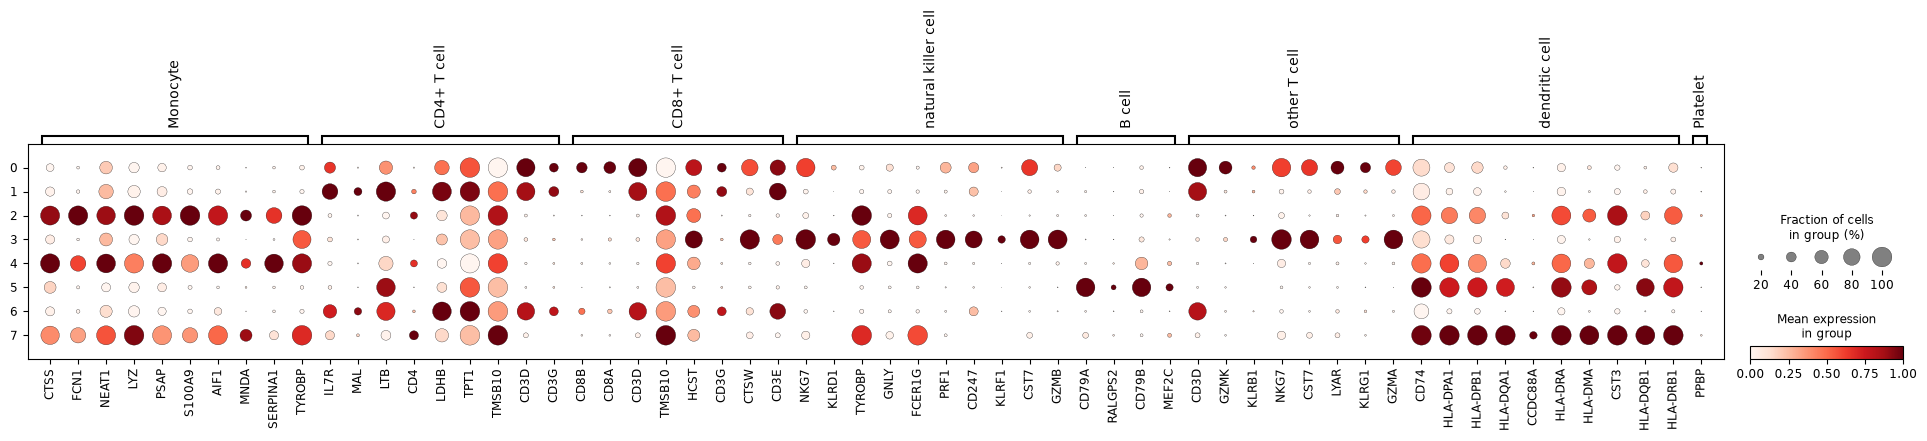

In [62]:
sc.pl.dotplot(adata_clean,markers,groupby="leiden_0.5",layer="log1p_norm",standard_scale="var")

In [63]:
cluster_names = {
    "0" : "CD8+ T cell",
    "1" : "CD4+ T cell", 
    "2" : "Monocyte",
    "3" : "Natural killer cell", 
    "4" : "Monocyte", 
    "5" : "B cell", 
    "6" : "CD4+ T cell", 
    "7" : "DC" 
} 

adata_clean.obs["cell_type"] = adata_clean.obs["leiden_0.5"].map(cluster_names)

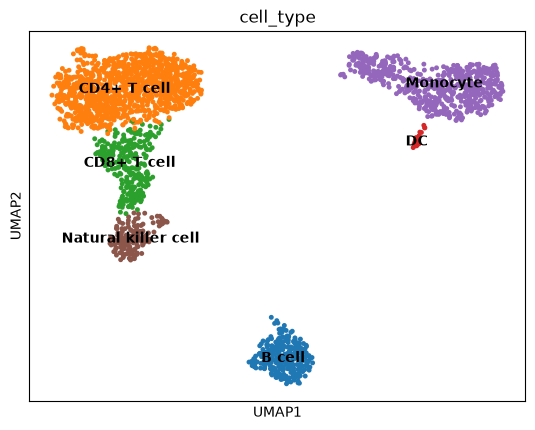

In [64]:
sc.pl.umap(adata_clean,layer="log1p_norm",color="cell_type",legend_loc="on data")

#### celltype.l2 (default)

In [65]:
markers_specific = {
    # --- B cells ---
    "B naive":           ["MS4A1", "TCL1A", "IL4R"],
    "B memory":          ["MS4A1", "AIM2", "TNFRSF13B"],
    "Plasmablast":       ["MZB1", "TNFRSF17", "DERL3"],

    # --- CD4 T cells ---
    "CD4 naive":         ["CCR7", "LEF1", "TCF7"],             # + no CD8A/CD8B
    "CD4 memory (TCM)":  ["IL7R", "AQP3", "S100A4"],
    "CD4 TEM":           ["IL7R", "GZMK", "KLRB1"],
    "Treg":              ["FOXP3", "IL2RA", "CTLA4", "RTKN2"],

    # --- CD8 T cells ---
    "CD8 naive":         ["CD8B", "S100B", "CCR7"],
    "CD8 TEM":           ["CD8A", "GZMH", "CCL5"],

    # --- Unconventional T cells ---
    "MAIT":              ["SLC4A10", "KLRB1", "NCR3"],

    # --- NK cells ---
    "NK (CD56dim)":      ["GNLY", "KLRF1", "PRF1"],
    "NK (CD56bright)":   ["XCL1", "XCL2", "NCAM1", "KLRC1"],

    # --- Monocytes ---
    "CD14 Mono":         ["CD14", "VCAN", "S100A12", "LYZ"],
    "CD16 Mono":         ["FCGR3A", "MS4A7", "CDKN1C"],

    # --- Dendritic cells ---
    "cDC2":              ["FCER1A", "CD1C", "CLEC10A"],
    "pDC":               ["LILRA4", "IL3RA", "SERPINF1"],

    # --- Others ---
    "Platelet":          ["PPBP", "PF4", "GNG11", "SDPR"],      # SDPR = old name of CAVIN2
    "Proliferating":     ["MKI67", "TOP2A"],
}

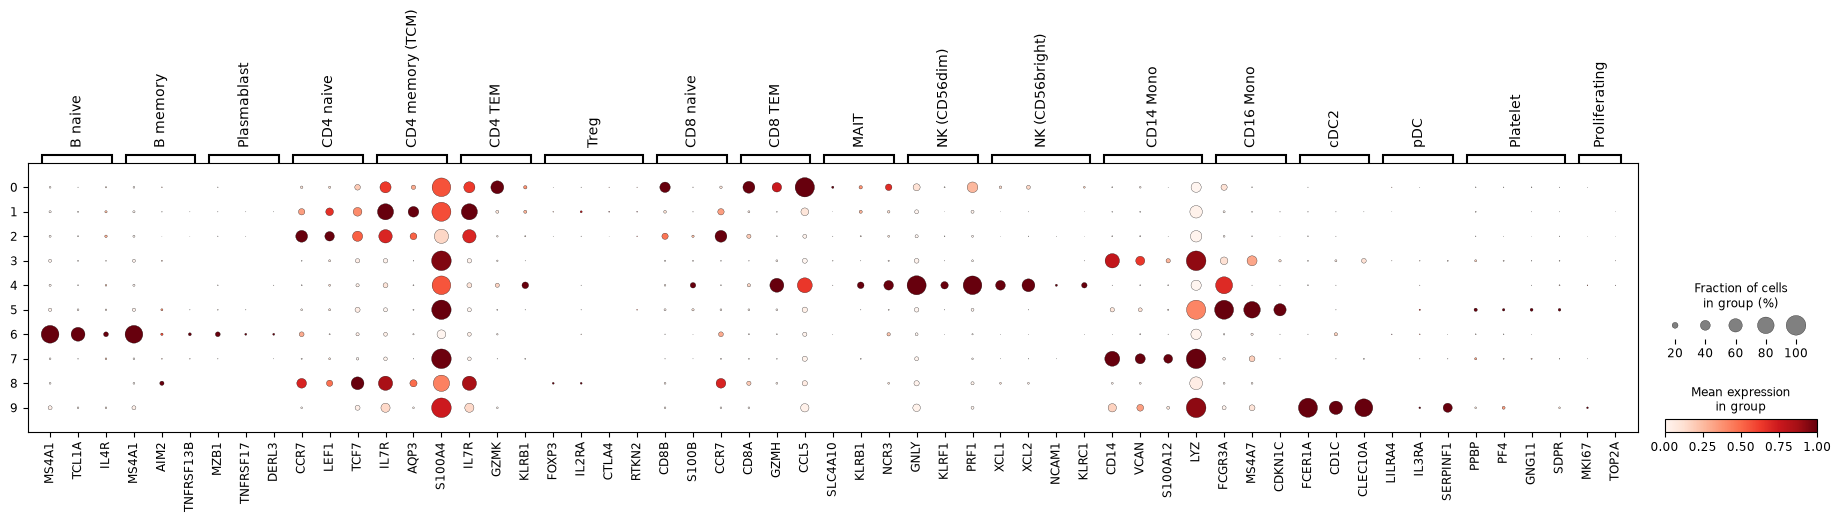

In [66]:
sc.pl.dotplot(adata_clean,markers_specific,groupby="leiden_1.0",layer="log1p_norm",standard_scale="var")

In [67]:
cluster_names_specific = {
    "0" : "CD8 TEM",
    "1" : "CD4 memory ", 
    "2" : "CD4 naive  ",
    "3" : "CD14 Mono", 
    "4" : "NK", 
    "5" : "CD16 Mono + some platelet", 
    "6" : "B cell", 
    "7" : "CD14 Mono",
    "8" : "CD4 naive + memory ",
    "9" : "cDC2"
} 

adata_clean.obs["cell_type_specific"] = adata_clean.obs["leiden_1.0"].map(cluster_names_specific)

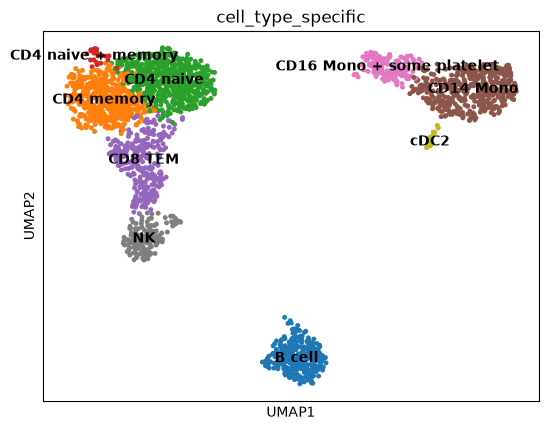

In [68]:
sc.pl.umap(adata_clean,layer="log1p_norm",color="cell_type_specific",legend_loc="on data")

In [69]:
sc.tl.rank_genes_groups(adata_clean, groupby="leiden_1.0", method="wilcoxon", layer="log1p_norm")
sc.get.rank_genes_groups_df(adata_clean, group="8").head(15)

,names,scores,logfoldchanges,pvals,pvals_adj
0,ISG15,7.531079,3.651632,5.032278e-14,6.783007e-10
1,IFI6,7.351710,3.481398,1.956874e-13,1.318835e-09
2,MX1,6.786182,3.500614,1.151399e-11,5.173236e-08
3,ISG20,6.386540,2.468379,1.696807e-10,5.717816e-07
4,IFITM1,5.506207,2.008206,3.666461e-08,9.884046e-05
5,LY6E,5.401979,1.766026,6.590944e-08,1.480656e-04
6,IFIT1,5.368196,4.369560,7.952792e-08,1.531367e-04
7,OAS1,5.018094,2.685756,5.218682e-07,8.792827e-04
8,MT2A,4.927045,2.702451,8.348239e-07,1.250288e-03
9,IFIT3,4.822666,3.799212,1.416522e-06,1.909329e-03


cluster 8 could be CD4 T cell in a different cell state , responding to interferon.

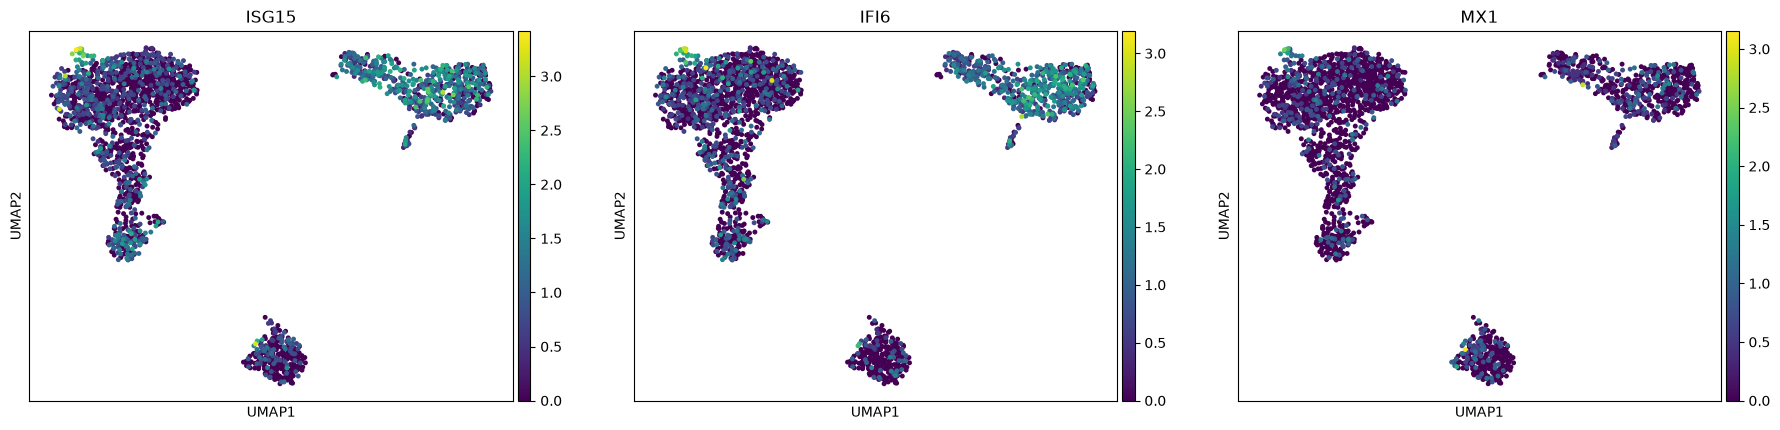

In [70]:
sc.pl.umap(adata_clean,layer="log1p_norm",color=["ISG15","IFI6","MX1"],legend_loc="on data")

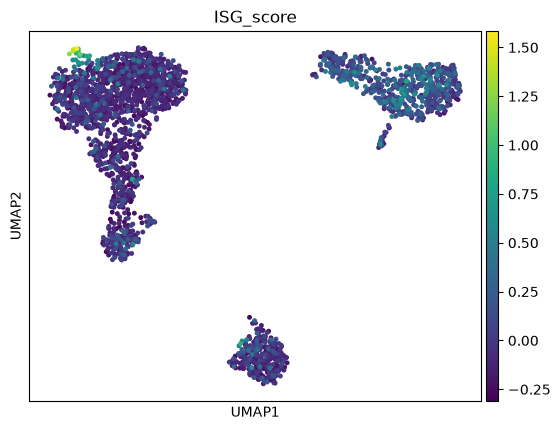

In [71]:
isg_genes = ["ISG15", "IFI6", "MX1", "IFIT1", "IFIT3", "OAS1", "IFI44L", "STAT1"]
sc.tl.score_genes(adata_clean, isg_genes, score_name="ISG_score", layer="log1p_norm")
sc.pl.umap(adata_clean, color="ISG_score")

one specific small group of CD4 T cells has a strong, coordinated interferon response. on top of baseline expression in monocyte of ISG15,IFI6

In [72]:
cluster_names_specific = {
    "0" : "CD8 TEM",
    "1" : "CD4 memory", 
    "2" : "CD4 naive",
    "3" : "CD14 Mono", 
    "4" : "NK", 
    "5" : "CD16 Mono + some platelet", 
    "6" : "B cells", 
    "7" : "CD14 Mono",
    "8" : "CD4 (IFN-responsive)",
    "9" : "cDC2"
} 

adata_clean.obs["cell_type_specific"] = adata_clean.obs["leiden_1.0"].map(cluster_names_specific)

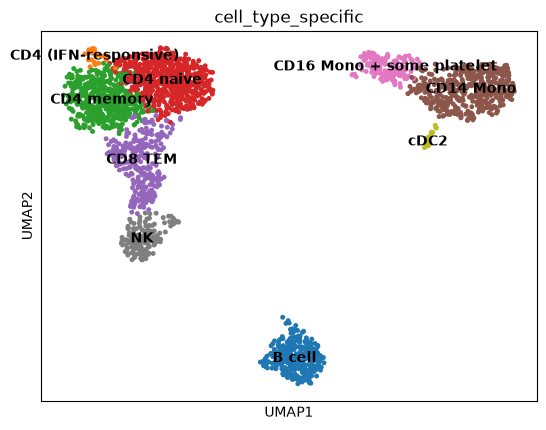

In [73]:
sc.pl.umap(adata_clean,layer="log1p_norm",color="cell_type_specific",legend_loc="on data")

In [80]:
# compare cluster 3 and 7 
sc.tl.rank_genes_groups(adata_clean, groupby="leiden_1.0", groups=["3"],reference="7", method="wilcoxon", layer="log1p_norm",key_added="mono_3_vs_7",) 
sc.get.rank_genes_groups_df(adata_clean, group="3", key="mono_3_vs_7").head(20)


,names,scores,logfoldchanges,pvals,pvals_adj
0,HLA-DPA1,12.710504,2.043116,5.170049e-37,2.322903e-33
1,HLA-DPB1,12.555757,2.060248,3.696317e-36,1.245566e-32
2,HLA-DRB1,12.174101,1.646145,4.270758e-34,1.151311e-30
3,CD74,11.965633,1.207999,5.378577e-33,1.208297e-29
4,HLA-DRA,11.787634,1.428234,4.520632e-32,8.704800e-29
5,HLA-DRB5,10.632243,1.713176,2.109764e-26,3.554689e-23
6,IFITM3,8.407655,1.561849,4.182919e-17,6.264619e-14
7,HLA-DQB1,7.642739,2.155944,2.126489e-14,2.866294e-11
8,HLA-DMA,7.198944,1.356897,6.068078e-13,7.435602e-10
9,IFITM2,7.023751,1.195637,2.159898e-12,2.426105e-09


most top gene are MHC class 2 gene . they form antigen presentation machinery -> cluster 3 has a stronger antigen-presenting profile than cluster 7  

In [83]:
cluster_names_specific = {
    "0" : "CD8 TEM",
    "1" : "CD4 memory", 
    "2" : "CD4 naive",
    "3" : "CD14 mono (HLA-2 high)", 
    "4" : "NK", 
    "5" : "CD16 Mono + some platelet", 
    "6" : "B cells", 
    "7" : "CD14 Mono",
    "8" : "CD4 (IFN-responsive)",
    "9" : "cDC2"
} 

adata_clean.obs["cell_type_specific"] = adata_clean.obs["leiden_1.0"].map(cluster_names_specific)

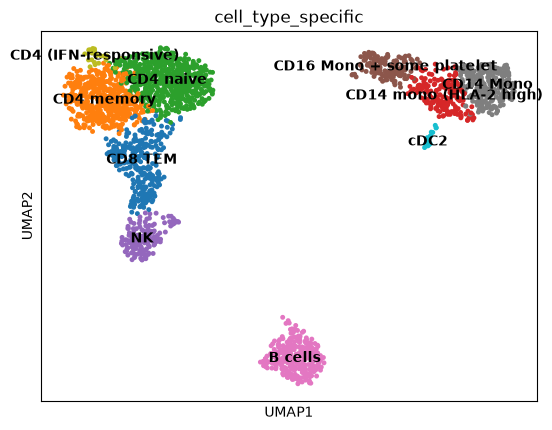

In [84]:
sc.pl.umap(adata_clean,layer="log1p_norm",color="cell_type_specific",legend_loc="on data")